# SEALS + machine learning -- learning to invert scattering
### the forward problem (size -> pattern) is classic; we LEARN the inverse (pattern -> size)

Mie/Rayleigh scattering is a solved *forward* problem: given a particle, you can
compute its angular scattering pattern. SEALS measures that pattern (encoded vs
wavelength). The useful question is the **inverse**: given a measured pattern, what
was the particle? That inverse has no clean closed form -- so we **learn** it with a
small neural net in PyTorch. This is the same shape as the dispersion-assisted GS
problem (recover the cause from an intensity measurement), and it ties the session's
math together: the net is **function approximation** (calc), its input is a **vector**
(linear algebra), and training is **gradient descent** (derivatives).

> Research note: inverse light scattering has been solved many ways (Mie inversion,
> lookup tables, optimization). The point here is not novelty -- it is *understanding*
> it by building the learned inverse end to end.

In [1]:
import numpy as np, matplotlib.pyplot as plt
import torch, torch.nn as nn
torch.manual_seed(0); np.random.seed(0)
print("torch", torch.__version__)

torch 2.11.0+cu128


## 1. The forward model (Rayleigh-Debye-Gans, numpy)

Same RDG scattering as `seals_intro.ipynb`: a particle of diameter $d$ produces
$I(\theta)$ whose **lobe spacing shrinks as $d$ grows**. That monotone structure is
what makes the inverse learnable -- the pattern's shape encodes the size.

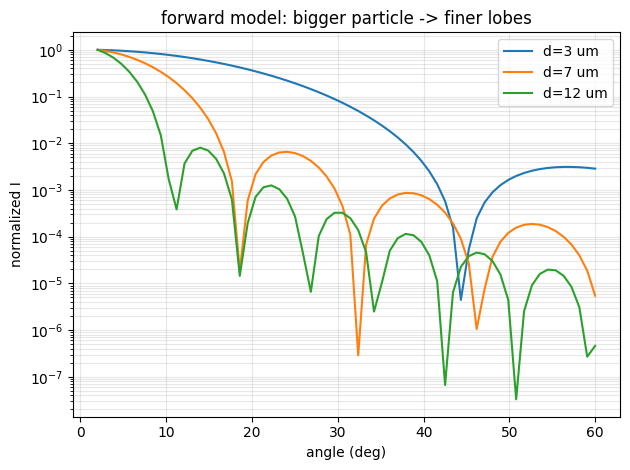

In [2]:
ANGLES = np.linspace(np.radians(2), np.radians(60), 64)   # the 64 'detector' angles
def form_factor_P(u):
    out = np.empty_like(u); s = np.abs(u) < 0.1
    out[s] = 1 - u[s]**2/10 + u[s]**4/280
    out[~s] = 3*(np.sin(u[~s]) - u[~s]*np.cos(u[~s]))/u[~s]**3
    return out
def rdg_pattern(dia, lam=1.59e-6, n_bg=1.0, n_sp=1.39):
    a = dia/2; k = 2*np.pi*n_bg/lam
    u = 2*k*a*np.sin(ANGLES/2)
    I = (form_factor_P(u)*(1+np.cos(ANGLES)**2))**2
    return I/ I.max()                                    # normalized pattern (shape only)

for d in (3e-6, 7e-6, 12e-6):
    plt.semilogy(np.degrees(ANGLES), rdg_pattern(d), label=f"d={d*1e6:.0f} um")
plt.xlabel("angle (deg)"); plt.ylabel("normalized I"); plt.legend()
plt.title("forward model: bigger particle -> finer lobes"); plt.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

## 2. Build a synthetic dataset (patterns -> diameters)

Draw many diameters, compute each pattern, add measurement noise. The **input** is
the 64-point pattern (a vector); the **target** is the diameter. Train/test split,
standardized features.

In [3]:
N = 4000
d_um = np.random.uniform(2, 15, N)                       # diameters 2-15 um
X = np.array([rdg_pattern(d*1e-6) for d in d_um])
X = np.log10(X + 1e-6)                                   # log scale (spans decades)
X += 0.03*np.random.randn(*X.shape)                      # 3% measurement noise
mu, sd = X.mean(0), X.std(0); X = (X-mu)/sd              # standardize columns
y = d_um.reshape(-1,1)

ntr = 3200
Xtr = torch.tensor(X[:ntr], dtype=torch.float32); ytr = torch.tensor(y[:ntr], dtype=torch.float32)
Xte = torch.tensor(X[ntr:], dtype=torch.float32); yte = torch.tensor(y[ntr:], dtype=torch.float32)
print("dataset:", X.shape, "->", y.shape, " | train", ntr, " test", N-ntr)

dataset: (4000, 64) -> (4000, 1)  | train 3200  test 800


## 3. A small PyTorch regressor + the training loop

A 2-hidden-layer MLP maps the 64-point pattern to one number (the diameter).
Training is plain **gradient descent on the mean-squared error** -- every step is
$\theta \leftarrow \theta - \eta\,\nabla_\theta\,\mathrm{MSE}$, the derivative doing
the work.

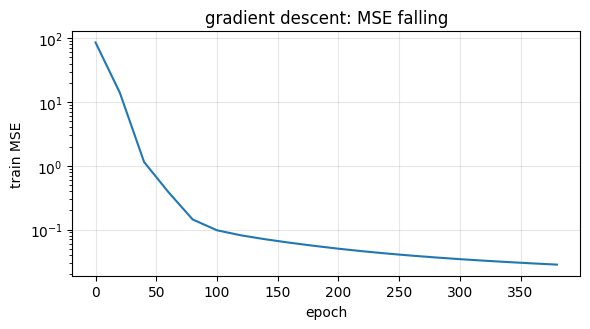

final train MSE = 0.0282 um^2


In [4]:
net = nn.Sequential(nn.Linear(64,64), nn.ReLU(), nn.Linear(64,32), nn.ReLU(), nn.Linear(32,1))
opt = torch.optim.Adam(net.parameters(), lr=3e-3); lossf = nn.MSELoss()
hist = []
for epoch in range(400):
    opt.zero_grad(); loss = lossf(net(Xtr), ytr); loss.backward(); opt.step()
    if epoch % 20 == 0: hist.append((epoch, float(loss.detach())))
plt.figure(figsize=(6,3.4))
plt.plot(*zip(*hist)); plt.xlabel("epoch"); plt.ylabel("train MSE"); plt.yscale("log")
plt.title("gradient descent: MSE falling"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print(f"final train MSE = {hist[-1][1]:.4f} um^2")

## 4. Evaluate -- predicted vs true diameter

On the held-out test set, the learned inverse recovers the diameter from the
pattern alone. The points hug the 45-degree line; $R^2$ near 1 means the net has
learned the inverse map.

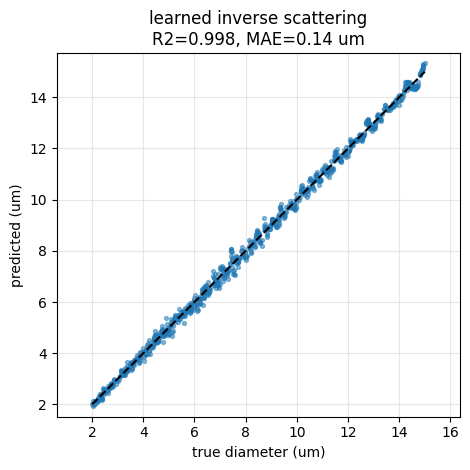

R2 = 0.9978,  mean abs error = 0.137 um


In [5]:
net.eval()
with torch.no_grad(): pred = net(Xte).numpy().ravel()
true = yte.numpy().ravel()
ss_res = np.sum((true-pred)**2); ss_tot = np.sum((true-true.mean())**2)
r2 = 1 - ss_res/ss_tot; mae = np.mean(np.abs(true-pred))
plt.figure(figsize=(4.8,4.8))
plt.scatter(true, pred, s=8, alpha=0.5)
plt.plot([2,15],[2,15],"k--"); plt.xlabel("true diameter (um)"); plt.ylabel("predicted (um)")
plt.title(f"learned inverse scattering\nR2={r2:.3f}, MAE={mae:.2f} um"); plt.axis("equal"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"R2 = {r2:.4f},  mean abs error = {mae:.3f} um")

## Takeaway

1. The **forward** scattering model is classic; the **inverse** (pattern -> particle)
   is what you actually want, and a small net learns it from data.
2. The pieces are this session's math: a pattern is a **vector**, the net is a
   **function approximator**, and training is **gradient descent** (derivatives).
3. Same shape as the GS receiver -- recover the hidden cause (size / phase) from an
   intensity-only measurement.

Solved before, yes -- but now built and understood end to end. Civilian education.